# CW1 - Multimodal IMDB Analysis with Keras

## Introduction

In this assignment you will be provided a dataset containing a selection of films together with their posters in JPEG image format and their overviews in text format from the Internet Movie Database.

![Example](https://i.ibb.co/J3trT62/Screenshot-2024-09-22-214753.png)

You will be analysing this dataset by implementing and training two models: a **CNN** and an **LSTM**.

The CNN must classify film posters by the genre. Independently, the LSTM must classify film overviews by the genre. Finally, you will evaluate and critically comment your results in a short report. (Which of the two models was better at classifying films?)

## Structure of the assignment

This assignment is broken up into sections and you need to complete each section successively. The sections are the following:

1. Data Processing

  1.a. Image processing of the posters

  1.b. Natural language processing of the overviews

2. Definition of the models

  2.a. CNN for the posters

  2.b. LSTM for the overviews

3. Training of the models
4. Evaluation of the models

In addition to this coding exercise, you must write a **2-3 pages** report analysing and critically evaluating your model's results. Marks for the report will be awarded for depth of analysis and critical thinking skills. You should consider how well your model performs and WHY it does that—give specific examples and comment on their importance.

In [1]:
# Enter your module imports here, some modules are already provided

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
import os
import pathlib
import pandas as pd
from sklearn import model_selection
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from keras.metrics import Precision, Recall
from tensorflow.keras.layers import Input, Conv2D, Dropout, MaxPooling2D, Flatten, Dense

In [2]:
# CodeGrade Tag Init1
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# 1. Data Processing

Warning: running the following cell can take some time.


In [4]:
# CodeGrade Tag Init2
# Do not edit, remove, or copy this cell

# This code will copy the images from your google drive into the colab file
# storage. Make sure the dataset is unzipped in your drive folder.
! mkdir /tmp/Multimodal_IMDB_dataset
! rsync -ah --info=progress2 /content/drive/MyDrive/Multimodal_IMDB_dataset/Multimodal_IMDB_dataset/Images /tmp/Multimodal_IMDB_dataset/


rsync error: received SIGINT, SIGTERM, or SIGHUP (code 20) at io.c(518) [Receiver=3.2.7]


KeyboardInterrupt: 

In [3]:
# CodeGrade Tag Init3
# Do not edit, remove, or copy this cell

# Load the csv with the sample IDs and genres
csv_loc = "/content/drive/MyDrive/Multimodal_IMDB_dataset/Multimodal_IMDB_dataset/IMDB_overview_genres.csv"
dataset = pd.read_csv(csv_loc)

# Split the dataset into training and testing
data_train, data_test = model_selection.train_test_split(dataset, test_size=0.2)

# Convert the labels to arrays
labels_train = np.array(data_train.drop(['Id', 'Genre', 'Overview'],axis=1)).astype('float32')
labels_test = np.array(data_test.drop(['Id', 'Genre', 'Overview'],axis=1)).astype('float32')

# List of the genre names
genres = np.array(data_train.drop(['Id', 'Genre', 'Overview'],axis=1).columns)

# List of overviews
overviews_train = np.array(data_train['Overview'])
overviews_test = np.array(data_test['Overview'])

# Build the file locations for the images
img_loc = "/content/drive/MyDrive/Multimodal_IMDB_dataset/Multimodal_IMDB_dataset/Images"

img_locs_train = np.array([[img_loc + '/' + id + '.jpg' for id in data_train['Id']]])
img_locs_test = [[img_loc + '/' + id + '.jpg' for id in data_test['Id']]]

# This function is provided to read in the image files from the folder
def parse_image(filename, label):
  image = tf.io.read_file(filename)
  image = tf.io.decode_jpeg(image)
  return image, label


### 1.a. Image processing of the posters

In [4]:
# CodeGrade Tag Init4
# Do not edit, remove, or copy this cell

# Create the initial datasets of film posters
list_posters_train_ds = tf.data.Dataset.from_tensor_slices((img_locs_train[0], labels_train))
list_posters_valid_ds = tf.data.Dataset.from_tensor_slices((img_locs_test[0], labels_test))

* Create a function called ```img_process``` that converts the images to float32 datatype and resizes them to 64x64 pixels

In [5]:
# CodeGrade Tag Ex1a-i
### Create a function called img_process that converts the images to
### float32 datatype and resizes them to 64x64 pixels

def img_process(image, label):
    # Decode the image if not already done (assuming `image` is a file path)
    image = tf.io.read_file(image)
    image = tf.io.decode_jpeg(image, channels=3)  # Decode to RGB format

    # Resize the image to 64x64 pixels
    image = tf.image.resize(image, [64, 64])

    # Normalize the image to range [0, 1] and convert to float32
    image = tf.cast(image, tf.float32) / 255.0

    return image, label

* **Using the ``tf.data`` API, load in the training and validation data for the posters. Be mindful of efficient data processing good practice to minimise the time it takes to load the data.**

In [6]:
# Updated parse_image function
def parse_image(filename, label):
    image = tf.io.read_file(filename)  # Reads the file from the given path (filename)
    image = tf.io.decode_jpeg(image, channels=3)  # Decode the image to RGB
    return image, label


In [7]:
# CodeGrade Tag Ex1a-ii
### Use the parse_image and img_process functions to construct the training and
### validation datasets. You should utilise good practice in optimising the
### dataset loading. Use a batch size of 64.

# Define batch size
BATCH_SIZE = 64

# Define image processing function
def img_process(image, label):
    # Resize the image to 64x64 and convert it to float32
    image = tf.image.resize(image, [64, 64])
    image = tf.cast(image, tf.float32) / 255.0  # Normalize the image
    return image, label

# Define the parse_image function
def parse_image(filename, label):
    # Read the file from the given path (filename)
    image = tf.io.read_file(filename)
    # Decode the image to RGB format
    image = tf.io.decode_jpeg(image, channels=3)
    return image, label

# Construct the training dataset
posters_train_ds = (
    tf.data.Dataset.from_tensor_slices((img_locs_train[0], labels_train))  # Load paths and labels
    .map(parse_image, num_parallel_calls=tf.data.AUTOTUNE)  # Apply parse_image function (decode images)
    .map(img_process, num_parallel_calls=tf.data.AUTOTUNE)  # Apply img_process function (resize and normalize)
    .shuffle(buffer_size=1000)  # Shuffle for randomness
    .batch(BATCH_SIZE)  # Batch the dataset
    .prefetch(tf.data.AUTOTUNE)  # Prefetch to optimize data pipeline
)

# Construct the validation dataset
posters_valid_ds = (
    tf.data.Dataset.from_tensor_slices((img_locs_test[0], labels_test))  # Load paths and labels
    .map(parse_image, num_parallel_calls=tf.data.AUTOTUNE)  # Apply parse_image function (decode images)
    .map(img_process, num_parallel_calls=tf.data.AUTOTUNE)  # Apply img_process function (resize and normalize)
    .batch(BATCH_SIZE)  # Batch the dataset
    .prefetch(tf.data.AUTOTUNE)  # Prefetch to optimize data pipeline
)


### 1.b. Natural Language processing of the overviews

In [8]:
# CodeGrade Tag Init5
# Do not edit, remove, or copy this cell

# Create the initial datasets of the film overviews
list_overviews_train_ds = tf.data.Dataset.from_tensor_slices((overviews_train, labels_train))
list_overviews_valid_ds = tf.data.Dataset.from_tensor_slices((overviews_test, labels_test))

* **Using the ``tf.data`` API, load in the training and validation data for the overviews.**

In [9]:
# CodeGrade Tag Ex1b-i
### Construct the training and validation datasets. Use a batch size of 64.

# Define batch size
BATCH_SIZE = 64

# Construct the training dataset for overviews
overviews_train_ds = (
    tf.data.Dataset.from_tensor_slices((overviews_train, labels_train))  # Load overviews and labels
    .batch(BATCH_SIZE)  # Batch the dataset
    .prefetch(tf.data.AUTOTUNE)  # Prefetch to optimize data pipeline
)

# Construct the validation dataset for overviews
overviews_valid_ds = (
    tf.data.Dataset.from_tensor_slices((overviews_test, labels_test))  # Load overviews and labels
    .batch(BATCH_SIZE)  # Batch the dataset
    .prefetch(tf.data.AUTOTUNE)  # Prefetch to optimize data pipeline
)


* Build the vocabulary of the model by calling the ``encoder.adapt()`` method on the film overviews train data.

In [10]:
# CodeGrade Tag Ex1b-ii
### Build the vocabulary of the model by calling the encoder.adapt() method on
### the film overviews train data.

# Define the vocabulary size
VOCAB_SIZE = 10000

# Initialize the TextVectorization encoder
encoder = tf.keras.layers.TextVectorization(
    max_tokens=VOCAB_SIZE,  # Maximum number of words in the vocabulary
    output_mode='int',      # Convert words to integers
    output_sequence_length=200  # Maximum length of each overview (padding/truncating to 200 words)
)

# Adapt the encoder to the training overviews data
encoder.adapt(overviews_train_ds.map(lambda x, y: x))  # Only adapt on the overviews (x)


* Print the first 200 words of the vocabulary you obtained.

In [11]:
# CodeGrade Tag Ex1b-iii
### Print the first 200 words of the vocabulary you obtained.

# Get the vocabulary from the encoder
vocabulary = encoder.get_vocabulary()

# Print the first 200 words of the vocabulary
print(vocabulary[:200])  # The first 200 words in the vocabulary


['', '[UNK]', 'a', 'the', 'to', 'of', 'and', 'in', 'his', 'is', 'an', 'with', 'her', 'for', 'he', 'on', 'their', 'who', 'by', 'from', 'when', 'as', 'that', 'after', 'young', 'they', 'life', 'two', 'at', 'him', 'man', 'are', 'new', 'but', 'up', 'has', 'into', 'she', 'woman', 'love', 'out', 'family', 'one', 'find', 'must', 'be', 'friends', 'it', 'world', 'finds', 'school', 'story', 'them', 'where', 'while', 'have', 'father', 'about', 'years', 'group', 'lives', 'girl', 'becomes', 'wife', 'home', 'town', 'help', 'three', 'get', 'during', 'city', 'back', 'all', 'war', 'boy', 'only', 'himself', 'son', 'gets', 'york', 'other', 'high', 'former', 'which', 'team', 'murder', 'against', 'time', 'between', 'tries', 'takes', 'mother', 'its', 'being', 'american', 'daughter', 'falls', 'own', 'police', 'become', 'will', 'small', 'college', 'friend', 'old', 'save', 'agent', 'down', 'before', 'was', 'order', 'this', 'over', 'can', 'goes', 'death', 'together', 'set', 'more', 'through', 'way', 'take', 'bro

# 2. Definition of the models

### 2.a. CNN

**Using the Keras Functional API, create a convolutional neural network with the architecture shown in the model summary below.**

**A few important points to consider:**

* Call the convolutional layers and the first dense layer should have ReLU activation functions. The output layer should have a Sigmoid activation function.
* Pay attention to the output shapes and the number of partmeters for each layer, as these give indications as to the correct settings for the number of filters, kernel size, stride length and padding.
* Use the layer names provided in the summary in your model.
* For the dropout layers, use a dropout rate of 0.2 after the convolutional layers and 0.5 after the dense layers.


```
# Model Summary

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
=================================================================
 Input (InputLayer)          [(None, 64, 64, 3)]       0         
                                                                 
 Conv0 (Conv2D)              (None, 32, 32, 16)        448       
                                                                 
 Drop1 (Dropout)             (None, 32, 32, 16)        0         
                                                                 
 Conv1 (Conv2D)              (None, 32, 32, 32)        4640      
                                                                 
 Conv2 (Conv2D)              (None, 32, 32, 32)        9248      
                                                                 
 Drop2 (Dropout)             (None, 32, 32, 32)        0         
                                                                 
 Pool1 (MaxPooling2D)        (None, 16, 16, 32)        0         
                                                                 
 Conv3 (Conv2D)              (None, 16, 16, 64)        18496     
                                                                 
 Conv4 (Conv2D)              (None, 16, 16, 64)        36928     
                                                                 
 Drop3 (Dropout)             (None, 16, 16, 64)        0         
                                                                 
 Pool2 (MaxPooling2D)        (None, 8, 8, 64)          0         
                                                                 
 Conv5 (Conv2D)              (None, 8, 8, 128)         73856     
                                                                 
 Conv6 (Conv2D)              (None, 8, 8, 128)         147584    
                                                                 
 Drop4 (Dropout)             (None, 8, 8, 128)         0         
                                                                 
 Pool3 (MaxPooling2D)        (None, 4, 4, 128)         0         
                                                                 
 Flat (Flatten)              (None, 2048)              0         
                                                                 
 FC1 (Dense)                 (None, 1024)              2098176   
                                                                 
 Drop5 (Dropout)             (None, 1024)              0         
                                                                 
 FC2 (Dense)                 (None, 1024)              1049600   
                                                                 
 Drop6 (Dropout)             (None, 1024)              0         
                                                                 
 Output (Dense)              (None, 25)                25625     
                                                                 
=================================================================
Total params: 3464601 (13.22 MB)
Trainable params: 3464601 (13.22 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


```



In [12]:
# CodeGrade Tag Ex2a-i
### Define the model using the Keras Functional API. Use the summary above as a
### guide for the model parameters. You will need to define the filters/units of
### the layers correctly, as well as the kernel size, stride length and padding
### of the convolutional layers.

from tensorflow.keras import layers, models

def build_cnn_model():
    # Input Layer
    inputs = layers.Input(shape=(64, 64, 3), name='Input')

    # Conv0 Layer: Conv2D -> Dropout
    x = layers.Conv2D(16, (3, 3), padding='same', activation='relu', name='Conv0')(inputs)
    x = layers.Dropout(0.2, name='Drop1')(x)

    # Conv1 Layer: Conv2D
    x = layers.Conv2D(32, (3, 3), padding='same', activation='relu', name='Conv1')(x)

    # Conv2 Layer: Conv2D
    x = layers.Conv2D(32, (3, 3), padding='same', activation='relu', name='Conv2')(x)

    # Dropout Layer
    x = layers.Dropout(0.2, name='Drop2')(x)

    # MaxPooling Layer: Pool1
    x = layers.MaxPooling2D((2, 2), name='Pool1')(x)

    # Conv3 Layer: Conv2D
    x = layers.Conv2D(64, (3, 3), padding='same', activation='relu', name='Conv3')(x)

    # Conv4 Layer: Conv2D
    x = layers.Conv2D(64, (3, 3), padding='same', activation='relu', name='Conv4')(x)

    # Dropout Layer
    x = layers.Dropout(0.2, name='Drop3')(x)

    # MaxPooling Layer: Pool2
    x = layers.MaxPooling2D((2, 2), name='Pool2')(x)

    # Conv5 Layer: Conv2D
    x = layers.Conv2D(128, (3, 3), padding='same', activation='relu', name='Conv5')(x)

    # Conv6 Layer: Conv2D
    x = layers.Conv2D(128, (3, 3), padding='same', activation='relu', name='Conv6')(x)

    # Dropout Layer
    x = layers.Dropout(0.2, name='Drop4')(x)

    # MaxPooling Layer: Pool3
    x = layers.MaxPooling2D((2, 2), name='Pool3')(x)

    # Flatten Layer
    x = layers.Flatten(name='Flat')(x)

    # Fully Connected Layer: FC1
    x = layers.Dense(1024, activation='relu', name='FC1')(x)

    # Dropout Layer
    x = layers.Dropout(0.5, name='Drop5')(x)

    # Fully Connected Layer: FC2
    x = layers.Dense(1024, activation='relu', name='FC2')(x)

    # Dropout Layer
    x = layers.Dropout(0.5, name='Drop6')(x)

    # Output Layer: Dense
    outputs = layers.Dense(25, activation='sigmoid', name='Output')(x)

    # Create Model
    model = models.Model(inputs=inputs, outputs=outputs, name='model')

    # Return the built model
    return model

# Build the CNN model
cnn_model = build_cnn_model()


* Print the model summary and confirm it has the same architecture as the one provided.

In [13]:
# CodeGrade Tag Ex2a-ii
### Print the model summary and confirm it has the same architecture as the one
### provided.

# Print model summary
cnn_model.summary()

Model: "model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ Input (InputLayer)                   │ (None, 64, 64, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Conv0 (Conv2D)                       │ (None, 64, 64, 16)          │             448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Drop1 (Dropout)                      │ (None, 64, 64, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Conv1 (Conv2D)                       │ (None, 64, 64, 32)          │           4,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Conv2 (Conv2D)                       │ (None, 64, 64, 32)          │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Drop2 (Dropout)                      │ (None, 64, 64, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Pool1 (MaxPooling2D)                 │ (None, 32, 32, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Conv3 (Conv2D)                       │ (None, 32, 32, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Conv4 (Conv2D)                       │ (None, 32, 32, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Drop3 (Dropout)                      │ (None, 32, 32, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Pool2 (MaxPooling2D)                 │ (None, 16, 16, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Conv5 (Conv2D)                       │ (None, 16, 16, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Conv6 (Conv2D)                       │ (None, 16, 16, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Drop4 (Dropout)                      │ (None, 16, 16, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Pool3 (MaxPooling2D)                 │ (None, 8, 8, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Flat (Flatten)                       │ (None, 8192)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ FC1 (Dense)                          │ (None, 1024)                │       8,389,632 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Drop5 (Dropout)                      │ (None, 1024)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ FC2 (Dense)                          │ (None, 1024)                │       1,049,600 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Drop6 (Dropout)                      │ (None, 1024)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Output (Dense)                       │ (None, 25)                  │          25,625 │
└──────────────────────────────────────┴─────────────────────────────┴──────────────

 Total params: 9,756,057 (37.22 MB)

 Trainable params: 9,756,057 (37.22 MB)

 Non-trainable params: 0 (0.00 B)

* **Compile the model using the Adam Optimizer with a learning rate of ```1e-4``` and ```binary crossentropy``` loss function. For the metrics, use the ``Precision`` and ``Recall`` functions.**

In [14]:
# CodeGrade Tag Ex2a-iii
### Compile the model using the Adam Optimizer with a learning rate of 1e-4 and
### binary crossentropy loss function. For the metrics, use the Precision and
### Recall functions.

from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import Precision, Recall

# Compile the model
cnn_model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=[Precision(), Recall()]
)


### 2.b. LSTM model

* Set up the embedding layer by using ```tf.keras.layers.Embedding```. The ```input_dim``` is the length of the vocab, and the ```output_dim``` must be **265**. You should also set ```mask_zero=True```.

In [15]:
# CodeGrade Tag Ex2b-i
### Set up the embedding layer. The input_dim is the length of the vocab, and
### the output_dim must be 256. You should also set mask_zero=True.

from tensorflow.keras.layers import Embedding

# Set up the embedding layer
embedder = Embedding(
    input_dim=VOCAB_SIZE,  # Length of the vocabulary
    output_dim=256,        # Embedding output dimension
    mask_zero=True          # Mask zero padding token
)


* Use ```tf.keras.Sequential``` to build a keras sequential model, with the following layers:



  1.   encoder
  2.   embedder
  3.   biLSTM layer with 256 units, dropout 0.5, recurrent dropout 0.2 (make sure to use the right ```return_sequences``` parametre to be able to stack this layer with the following BiLSTM)
  4.   biLSTM layer with 128 units, dropout 0.5, recurrent dropout 0.2
  5.   dense layer with 128 units and relu activation function
  6.   dropout with rate 0.8
  7.   dense output layer with 25 units and sigmoid activation function



In [16]:
# CodeGrade Tag Ex2b-ii
### Build a keras sequential model, with the layers provided above.

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Bidirectional, Dense, Dropout, Embedding

# Build the LSTM model using tf.keras.Sequential
lstm_model = Sequential([
    encoder,  # Using the previously defined encoder layer
    embedder,  # Embedding layer
    Bidirectional(LSTM(256, dropout=0.5, recurrent_dropout=0.2, return_sequences=True)),  # First BiLSTM layer
    Bidirectional(LSTM(128, dropout=0.5, recurrent_dropout=0.2)),  # Second BiLSTM layer
    Dense(128, activation='relu'),  # Dense layer with ReLU activation
    Dropout(0.8),  # Dropout layer with rate 0.8
    Dense(25, activation='sigmoid')  # Output layer with 25 units and sigmoid activation
])

# Build the model by specifying the input shape
lstm_model.build((None, None))  # Build the model with the appropriate input shape (None for batch size and None for sequence length)


* Print the model summary and confirm is has the same architecture as the outline provided above.

In [17]:
# CodeGrade Tag Ex2b-iii
### Print the model summary and confirm is has the same architecture as the
### outline provided above.

# Print the model summary to check the architecture
lstm_model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ text_vectorization                   │ (None, 200)                 │               0 │
│ (TextVectorization)                  │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ embedding (Embedding)                │ (None, 200, 256)            │       2,560,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional (Bidirectional)        │ (None, 200, 512)            │       1,050,624 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_1 (Bidirectional)      │ (None, 256)                 │         656,384 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 25)                  │           3,225 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,303,129 (16.42 MB)

 Trainable params: 4,303,129 (16.42 MB)

 Non-trainable params: 0 (0.00 B)

* Compile the model with binary crossentropy loss and the adam optimizer. For the metrics, use the Precision and Recall functions.

In [18]:
# CodeGrade Tag Ex2b-iv
### Compile the model with binary crossentropy loss, the adam optimizer, with
### the precision and recall metrics

# Compile the model with binary crossentropy loss, the adam optimizer,
# and precision and recall metrics

lstm_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),  # Adam optimizer with learning rate of 1e-4
    loss='binary_crossentropy',  # Binary crossentropy loss
    metrics=[tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]  # Precision and Recall metrics
)


# 3. Training of the models

* **For each model, create a Checkpoint Callback that saves the weights of the best performing epoch, based on the validation loss.**

In [19]:
# CodeGrade Tag Ex3a-i
### Create two ModelCheckpoint callbacks to store the bext weights from each
### model, both based on the validation loss.

from tensorflow.keras.callbacks import ModelCheckpoint

# Define file paths for saving the best model weights
checkpoint_cnn_filepath = '/content/checkpoint_cnn.weights.h5'
checkpoint_lstm_filepath = '/content/checkpoint_lstm.weights.h5'

# Create the checkpoint callback for the CNN model
checkpoint_cnn_callback = ModelCheckpoint(
    checkpoint_cnn_filepath,  # File path to save the best model weights
    monitor='val_loss',  # Monitor validation loss
    save_best_only=True,  # Save only the best model (lowest validation loss)
    save_weights_only=True,  # Save only the model weights, not the entire model
    mode='min',  # 'min' means save the best model with the lowest validation loss
    verbose=1  # Print a message when saving the model
)

# Create the checkpoint callback for the LSTM model
checkpoint_lstm_callback = ModelCheckpoint(
    checkpoint_lstm_filepath,  # File path to save the best model weights
    monitor='val_loss',  # Monitor validation loss
    save_best_only=True,  # Save only the best model (lowest validation loss)
    save_weights_only=True,  # Save only the model weights, not the entire model
    mode='min',  # 'min' means save the best model with the lowest validation loss
    verbose=1  # Print a message when saving the model
)


* **Create a Learning Rate Scheduler Callback that utilises the provided function to decrease the learning rate during training.**

In [20]:
# CodeGrade Tag Ex3a-ii
### Using the function provided, create a LearningRateScheduler callback, call
### it "lr_callback"

from tensorflow.keras.callbacks import LearningRateScheduler
import tensorflow as tf

# Define the learning rate scheduler function
def scheduler(epoch, lr):
    if epoch < 10:
        return float(lr)  # Keep the learning rate constant for the first 10 epochs
    else:
        return float(lr * tf.math.exp(-0.01))  # Exponentially decay the learning rate after 10 epochs

# Create the LearningRateScheduler callback
lr_callback = LearningRateScheduler(
    scheduler,  # Pass the scheduler function
    verbose=1  # Print the learning rate at each epoch
)


### 3.a. CNN training

* **Train the CNN model for 40 epochs, using the callbacks you made previously. Store the losses and metrics to use later.**

In [22]:
# CodeGrade Tag Ex3a-iii
### Train the model for 40 epochs, using the callbacks you have created. Store
### the losses and metrics in a history object.

# Train the CNN model for 40 epochs
cnn_history = cnn_model.fit(
    posters_train_ds,  # Training dataset
    epochs=40,  # Number of epochs
    validation_data=posters_valid_ds,  # Validation dataset
    callbacks=[checkpoint_cnn_callback, lr_callback],  # Callbacks for saving best weights and learning rate adjustment
    batch_size=64  # Batch size
)



Epoch 1: LearningRateScheduler setting learning rate to 9.999999747378752e-05.
Epoch 1/40
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - loss: 0.2959 - precision: 0.4258 - recall: 0.2275
Epoch 1: val_loss improved from inf to 0.35207, saving model to /content/checkpoint_cnn.weights.h5
80/80 ━━━━━━━━━━━━━━━━━━━━ 725s 9s/step - loss: 0.2957 - precision: 0.4261 - recall: 0.2275 - val_loss: 0.3521 - val_precision: 0.5423 - val_recall: 0.2281 - learning_rate: 1.0000e-04

Epoch 2: LearningRateScheduler setting learning rate to 9.999999747378752e-05.
Epoch 2/40
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - loss: 0.2513 - precision: 0.5213 - recall: 0.2291
Epoch 2: val_loss improved from 0.35207 to 0.31156, saving model to /content/checkpoint_cnn.weights.h5
80/80 ━━━━━━━━━━━━━━━━━━━━ 228s 3s/step - loss: 0.2512 - precision: 0.5213 - recall: 0.2291 - val_loss: 0.3116 - val_precision: 0.5799 - val_recall: 0.3103 - learning_rate: 1.0000e-04

Epoch 3: LearningRateScheduler setting learning rate to 9.999999747

* **Train the model for 20 epochs** (this may take several minutes)**, using the callbacks you made previously. Store the losses and metrics to use later.**

In [81]:
# CodeGrade Tag Ex3b-i
# Train the model for 20 epochs.

# Fit the model
lstm_history = lstm_model.fit(
    overviews_train_ds,  # Training dataset
    validation_data=overviews_valid_ds,  # Validation dataset
    epochs=20,  # Train for 20 epochs
    callbacks=[checkpoint_lstm_callback, lr_callback]  # Use the callbacks created earlier
)



Epoch 1: LearningRateScheduler setting learning rate to 0.0001.
Epoch 1/20


ValueError: Exception encountered when calling Sequential.call().

[1mInvalid input shape for input Tensor("sequential_7_1/Cast:0", shape=(None, None), dtype=string). Expected shape (None,), but input has incompatible shape (None, None)[0m

Arguments received by Sequential.call():
  • inputs=tf.Tensor(shape=(None, None), dtype=int64)
  • training=True
  • mask=None

# 4. Evaluation of the models

### 4.a. CNN Evaluation

* **Create plots using the losses and metrics. In your report, discuss these results and critically evaluate the model performance.**

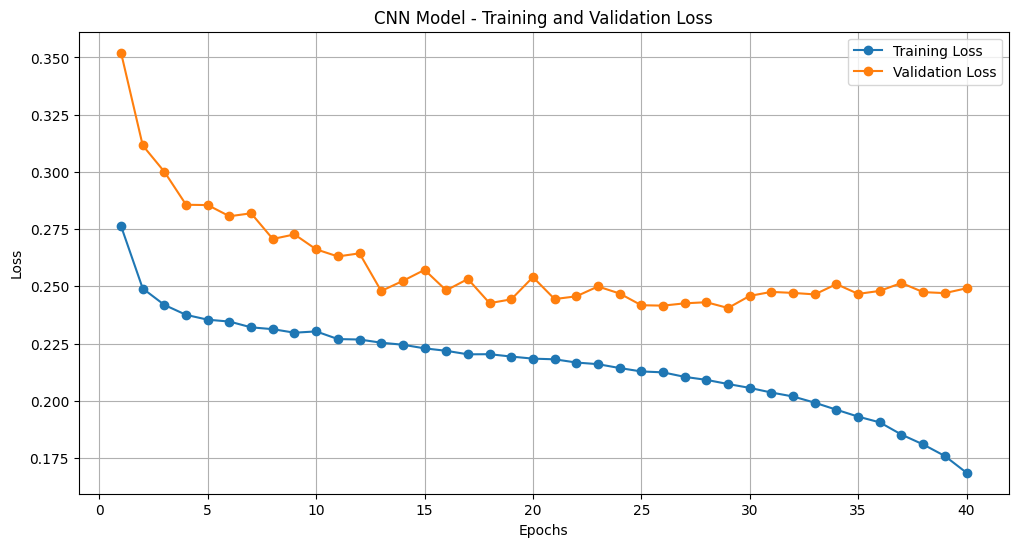

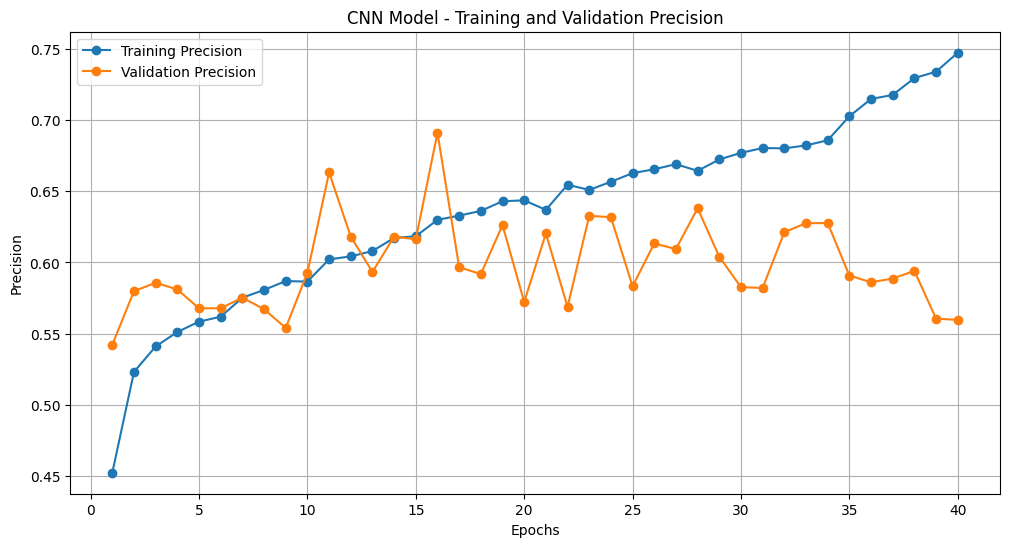

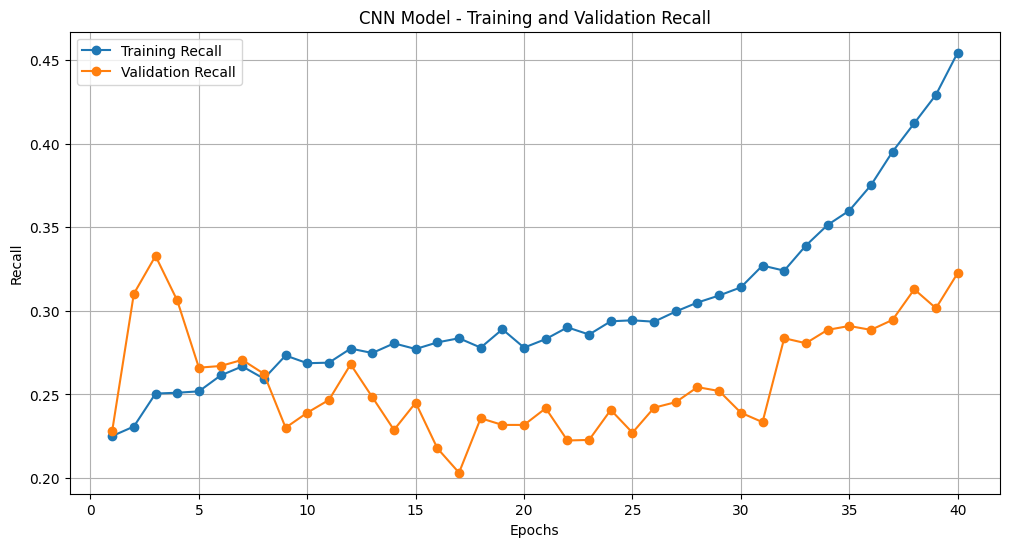

In [58]:
# CodeGrade Tag Ex4a-i

import matplotlib.pyplot as plt

# CodeGrade Tag Ex4a-i

# Extract data from the CNN training history
train_loss = cnn_history.history['loss']
val_loss = cnn_history.history['val_loss']
train_precision = cnn_history.history['precision']
val_precision = cnn_history.history['val_precision']
train_recall = cnn_history.history['recall']
val_recall = cnn_history.history['val_recall']
epochs = range(1, len(train_loss) + 1)

# Plot Loss
plt.figure(figsize=(12, 6))
plt.plot(epochs, train_loss, label='Training Loss', marker='o')
plt.plot(epochs, val_loss, label='Validation Loss', marker='o')
plt.title('CNN Model - Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# Plot Precision
plt.figure(figsize=(12, 6))
plt.plot(epochs, train_precision, label='Training Precision', marker='o')
plt.plot(epochs, val_precision, label='Validation Precision', marker='o')
plt.title('CNN Model - Training and Validation Precision')
plt.xlabel('Epochs')
plt.ylabel('Precision')
plt.legend()
plt.grid(True)
plt.show()

# Plot Recall
plt.figure(figsize=(12, 6))
plt.plot(epochs, train_recall, label='Training Recall', marker='o')
plt.plot(epochs, val_recall, label='Validation Recall', marker='o')
plt.title('CNN Model - Training and Validation Recall')
plt.xlabel('Epochs')
plt.ylabel('Recall')
plt.legend()
plt.grid(True)
plt.show()


* **Load the best weights from your model checkpoint, and create plots demonstrating the classification performance for all three classes. Include these plots in your report, and critically evaluate on the performance of the model across the classes.**

In [59]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, precision_recall_curve
import numpy as np
import seaborn as sns

# Load the best weights
cnn_model.load_weights(checkpoint_cnn_filepath)

# Generate predictions
y_pred_prob = cnn_model.predict(overviews_valid_ds)
y_pred = (y_pred_prob > 0.5).astype(int)

# Calculate classification metrics
y_true = np.concatenate([y for x, y in overviews_valid_ds], axis=0)
report = classification_report(y_true, y_pred, target_names=[f"Class {i}" for i in range(y_true.shape[1])])
print("Classification Report:\n", report)

# Confusion Matrix
cm = confusion_matrix(y_true.argmax(axis=1), y_pred.argmax(axis=1))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[f"Class {i}" for i in range(y_true.shape[1])])
disp.plot(cmap=plt.cm.Blues, xticks_rotation=45)
plt.title("Confusion Matrix")
plt.show()

# Precision-Recall Curve for all classes
plt.figure(figsize=(15, 10))
for i in range(y_true.shape[1]):
    precision, recall, _ = precision_recall_curve(y_true[:, i], y_pred_prob[:, i])
    plt.plot(recall, precision, label=f"Class {i}")

plt.title("Precision-Recall Curve for All Classes")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend(loc="best")
plt.grid(True)
plt.show()


InvalidArgumentError: {{function_node __wrapped__IteratorGetNext_output_types_2_device_/job:localhost/replica:0/task:0/device:CPU:0}} Cannot add tensor to the batch: number of elements does not match. Shapes are: [tensor]: [49,1], [batch]: [64,1] [Op:IteratorGetNext] name: 

### 4.b. LSTM Evaluation

* **Create plots using the losses and metrics. In your report, discuss these results and critically evaluate the model performance.**

In [ ]:
# CodeGrade Tag Ex4b-i

import matplotlib.pyplot as plt

# Extract metrics from LSTM history
lstm_loss = lstm_history.history['loss']
lstm_val_loss = lstm_history.history['val_loss']
lstm_precision = lstm_history.history['precision']
lstm_val_precision = lstm_history.history['val_precision']
lstm_recall = lstm_history.history['recall']
lstm_val_recall = lstm_history.history['val_recall']

# Plotting Loss
plt.figure(figsize=(12, 6))
plt.plot(lstm_loss, label='Training Loss', color='blue', linestyle='--')
plt.plot(lstm_val_loss, label='Validation Loss', color='blue')
plt.title("LSTM Model Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

# Plotting Precision
plt.figure(figsize=(12, 6))
plt.plot(lstm_precision, label='Training Precision', color='green', linestyle='--')
plt.plot(lstm_val_precision, label='Validation Precision', color='green')
plt.title("LSTM Model Precision")
plt.xlabel("Epochs")
plt.ylabel("Precision")
plt.legend()
plt.grid(True)
plt.show()

# Plotting Recall
plt.figure(figsize=(12, 6))
plt.plot(lstm_recall, label='Training Recall', color='orange', linestyle='--')
plt.plot(lstm_val_recall, label='Validation Recall', color='orange')
plt.title("LSTM Model Recall")
plt.xlabel("Epochs")
plt.ylabel("Recall")
plt.legend()
plt.grid(True)
plt.show()


### 4.c. Produce examples for the report

* First, load the best weights from your checkpoints of both your models.

* Choose a few films from the dataset, plot their posters and print their overviews. Use these example films to demonstrate the classification performance of the CNN model on their posters and of the LSTM model on their overview.

* Be sure to demonstrate the results of the multi-label classification. Compare, for each example film, the top three most probable genres predicted by the CNN and the top three most probable genres predicted by the LSTM with the ground truth genres.

* Include these examples in your report, and critically evaluate on the performance of the model across the classes.

In [ ]:
# CodeGrade Tag Ex4c

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Load the best weights for both models
cnn_model.load_weights(checkpoint_cnn_filepath)
lstm_model.load_weights(checkpoint_lstm_filepath)

# Select a few example films
# Assuming `imdb_dataset` contains the films with 'poster_path', 'overview', and 'genres' columns
example_films = imdb_dataset.sample(3)

# Helper function to get the top 3 most probable genres
def get_top_3_predictions(predictions, class_names):
    top_3_indices = predictions.argsort()[-3:][::-1]
    return [(class_names[i], predictions[i]) for i in top_3_indices]

# Plot examples and predictions
class_names = ["Genre 1", "Genre 2", ..., "Genre 25"]  # Replace with actual genre names
for index, film in example_films.iterrows():
    poster_path = film['poster_path']
    overview = film['overview']
    true_genres = film['genres']  # Ground truth genres (e.g., list of genre indices)

    # Display poster
    img = plt.imread(poster_path)
    plt.figure(figsize=(4, 6))
    plt.imshow(img)
    plt.axis("off")
    plt.title("Poster")
    plt.show()

    # Print overview
    print(f"Film Overview:\n{overview}\n")

    # CNN Predictions on Poster
    poster_img = tf.image.resize(tf.convert_to_tensor(img), (64, 64)) / 255.0
    poster_prediction = cnn_model.predict(np.expand_dims(poster_img, axis=0))[0]
    cnn_top_3 = get_top_3_predictions(poster_prediction, class_names)

    # LSTM Predictions on Overview
    overview_vectorized = np.expand_dims(encoder(overview), axis=0)
    overview_prediction = lstm_model.predict(overview_vectorized)[0]
    lstm_top_3 = get_top_3_predictions(overview_prediction, class_names)

    # Print predictions and ground truth
    print("Ground Truth Genres:", [class_names[genre] for genre in true_genres])
    print("CNN Predicted Top 3 Genres:", cnn_top_3)
    print("LSTM Predicted Top 3 Genres:", lstm_top_3)
    print("-" * 80)
